# A2: R2Gen + Retrieval — Ablation Study
**Model**: R2Gen (exact source code) + Image/Text Retrieval augmentation  
**Dataset**: Indiana University Chest X-Ray  
**Metrics**: BLEU-1, BLEU-2, BLEU-3, BLEU-4, ROUGE-L  
**Preprocessing**: Same `processed_outputs.zip` as all other ablation models

> ⚠️ **Before running**: Runtime → Change runtime type → **T4 GPU**


## ✅ Step 1 — Verify GPU

In [3]:
import torch
if not torch.cuda.is_available():
    raise RuntimeError("No GPU! Go to Runtime → Change runtime type → T4 GPU")
print(f"✅ GPU     : {torch.cuda.get_device_name(0)}")
print(f"   VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"   PyTorch: {torch.__version__}")


✅ GPU     : NVIDIA GeForce RTX 2080 Ti
   VRAM   : 11.5 GB
   PyTorch: 2.6.0+cu124


## 📦 Step 2 — Clone R2Gen & install libraries

In [4]:
import os

# Clone R2Gen source code
if not os.path.exists("R2Gen"):
    os.system("git clone https://github.com/cuhksz-nlp/R2Gen.git")
    print("✅ R2Gen cloned.")
else:
    print("✅ R2Gen already exists.")

# Add R2Gen to path so we can import its modules
import sys
sys.path.insert(0, "R2Gen")
print("✅ R2Gen added to path.")

# Install required packages
os.system("pip install rouge-score nltk faiss-cpu -q")

import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
print("✅ All packages installed.")


✅ R2Gen already exists.
✅ R2Gen added to path.
✅ All packages installed.


## 📂 Step 3 — Set paths

In [5]:
from pathlib import Path

PROJECT_DIR    = Path("/home/jupyter-st126671/data/iu_xray_a2")
RAW_DIR        = PROJECT_DIR / "dataset" / "raw"
PROCESSED_DIR  = PROJECT_DIR / "dataset" / "processed"
IMAGES_DIR     = RAW_DIR / "images" / "images_normalized"
OUTPUT_DIR     = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"

for d in [RAW_DIR, PROCESSED_DIR, OUTPUT_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

best_ckpt = CHECKPOINT_DIR / "best_model_a2.pt"

print("✅ Paths set.")
print(f"   Checkpoint : {best_ckpt}")


✅ Paths set.
   Checkpoint : /home/jupyter-st126671/data/iu_xray_a2/checkpoints/best_model_a2.pt


## 💾 Step 4 — Load processed CSV files

In [6]:
import zipfile
from pathlib import Path

# 👉 Set your ZIP file path here (update this)
zip_path = Path("/home/jupyter-st126671/processed_data/processed.zip")   # or full path like: Path("/Users/yourname/Downloads/processed_outputs.zip")

# 👉 Directory where files will be extracted
PROCESSED_DIR = Path("./processed_data")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as zf:
    zf.extractall(PROCESSED_DIR)
    print("Extracted:", zf.namelist())

# Define file paths
TRAIN_CSV = PROCESSED_DIR / "train.csv"
VAL_CSV   = PROCESSED_DIR / "val.csv"
TEST_CSV  = PROCESSED_DIR / "test.csv"
LABEL_MAP = PROCESSED_DIR / "problem_label_map.json"

# Check files
for fname, path in [
    ("train.csv", TRAIN_CSV),
    ("val.csv", VAL_CSV),
    ("test.csv", TEST_CSV),
    ("problem_label_map.json", LABEL_MAP)
]:
    print(f"  {'✅' if path.exists() else '❌ MISSING'}  {fname}")

print("\n✅ Processed files ready.")

Extracted: ['processed/', '__MACOSX/._processed', 'processed/master_dataset.csv', '__MACOSX/processed/._master_dataset.csv', 'processed/val.csv', '__MACOSX/processed/._val.csv', 'processed/test.csv', '__MACOSX/processed/._test.csv', 'processed/train.csv', '__MACOSX/processed/._train.csv', 'processed/ppked_test.csv', '__MACOSX/processed/._ppked_test.csv', 'processed/ppked_train.csv', '__MACOSX/processed/._ppked_train.csv', 'processed/problem_label_map.json', '__MACOSX/processed/._problem_label_map.json', 'processed/ppked_val.csv', '__MACOSX/processed/._ppked_val.csv']
  ✅  train.csv
  ✅  val.csv
  ✅  test.csv
  ✅  problem_label_map.json

✅ Processed files ready.


## 📥 Step 5 — Download images from Kaggle

In [7]:
import os
import json
import shutil
from pathlib import Path

# =========================
# 1. SET YOUR KAGGLE INFO
# =========================
KAGGLE_USERNAME = "dakchhyetashrestha"
KAGGLE_KEY = "KGAT_d5402c4da1d75091018ba959a85a8b80"

# =========================
# 2. PATHS
# =========================
RAW_DIR = Path("./raw_data")
IMAGES_DIR = Path("./images")
RAW_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# =========================
# 3. CREATE ~/.kaggle/kaggle.json
# =========================
kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)

kaggle_json_path = kaggle_dir / "kaggle.json"
with open(kaggle_json_path, "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

os.chmod(kaggle_json_path, 0o600)
print(f"✅ kaggle.json created at: {kaggle_json_path}")

# =========================
# 4. DOWNLOAD WITH PYTHON API
# =========================
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

api.dataset_download_files(
    "raddar/chest-xrays-indiana-university",
    path=str(RAW_DIR),
    unzip=True
)

print("✅ Dataset downloaded")

# =========================
# 5. FIND images_normalized
# =========================
def find_dir(root, name):
    matches = [p for p in root.rglob(name) if p.is_dir()]
    if not matches:
        raise FileNotFoundError(f"❌ '{name}' not found under {root}")
    return matches[0]

images_src = find_dir(RAW_DIR, "images_normalized")
print("✅ Found images folder:", images_src)

# =========================
# 6. COPY IMAGES
# =========================
if images_src.resolve() != IMAGES_DIR.resolve():
    if IMAGES_DIR.exists():
        shutil.rmtree(IMAGES_DIR)
    shutil.copytree(images_src, IMAGES_DIR)

img_count = len(list(IMAGES_DIR.glob("*.png")))
print(f"✅ {img_count} images ready in: {IMAGES_DIR}")

✅ kaggle.json created at: /home/jupyter-st126671/.kaggle/kaggle.json
Dataset URL: https://www.kaggle.com/datasets/raddar/chest-xrays-indiana-university
✅ Dataset downloaded
✅ Found images folder: raw_data/images/images_normalized
✅ 4783 images ready in: images


## 🔧 Step 6 — Rebuild full image paths in CSVs

In [8]:
import pandas as pd
from pathlib import Path

PROCESSED_DIR = Path("./processed_data")   # change if needed
IMAGES_DIR = Path("./images")

TRAIN_CSV = PROCESSED_DIR / "train.csv"
VAL_CSV   = PROCESSED_DIR / "val.csv"
TEST_CSV  = PROCESSED_DIR / "test.csv"

def rebuild_paths(csv_path, images_dir):
    df = pd.read_csv(csv_path)

    for col in ["frontal_path", "lateral_path"]:
        if col in df.columns:
            def fix_path(x):
                if pd.isna(x):
                    return x
                fn = Path(str(x).strip()).name
                return str(images_dir / fn)

            df[col] = df[col].apply(fix_path)

    df.to_csv(csv_path, index=False)
    return df

for csv_path in [TRAIN_CSV, VAL_CSV, TEST_CSV]:
    if not csv_path.exists():
        print(f"❌ Missing: {csv_path}")
        continue

    df = rebuild_paths(csv_path, IMAGES_DIR)

    sample_front = df["frontal_path"].iloc[0] if "frontal_path" in df.columns else None
    exists = Path(sample_front).exists() if sample_front else False

    print(f"{csv_path.name:12}: {df.shape[0]} rows | {'✅ exists' if exists else '❌ NOT FOUND'}")
    if sample_front:
        print("   sample:", sample_front)

print("\n✅ Paths rebuilt.")

train.csv   : 2060 rows | ✅ exists
   sample: images/167_IM-0441-1001.dcm.png
val.csv     : 441 rows | ✅ exists
   sample: images/1320_IM-0207-1001.dcm.png
test.csv    : 442 rows | ❌ NOT FOUND
   sample: images/3374_IM-1624-1001.dcm.png

✅ Paths rebuilt.


## 🔧 Step 7 — Imports

In [9]:
import re, json, os, copy, math, warnings, time
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
from torchvision import transforms
from PIL import Image
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from tqdm import tqdm
import faiss

warnings.filterwarnings("ignore")
print("✅ All imports OK")


✅ All imports OK


## ⚙️ Step 8 — Hyperparameters

In [10]:
SEED           = 42
BATCH_SIZE     = 16
NUM_EPOCHS     = 5
LR             = 1e-4
MAX_SEQ_LEN    = 60
IMAGE_SIZE     = 224
TOP_K          = 3
D_MODEL        = 512
D_FF           = 512
NUM_HEADS      = 8
NUM_LAYERS     = 3
DROPOUT        = 0.1
RM_NUM_SLOTS   = 3
RM_NUM_HEADS   = 1        # ← changed from 8 to 1 (R2Gen paper default)
RM_D_MODEL     = 512
NUM_WORKERS    = 2
DEVICE         = torch.device("cuda")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device     : {DEVICE}  ({torch.cuda.get_device_name(0)})")
print(f"Batch size : {BATCH_SIZE}")
print(f"Epochs     : {NUM_EPOCHS}")
print(f"Top-K      : {TOP_K}")
print(f"D_Model    : {D_MODEL}")

Device     : cuda  (NVIDIA GeForce RTX 2080 Ti)
Batch size : 16
Epochs     : 5
Top-K      : 3
D_Model    : 512


## 📖 Step 9 — R2Gen Tokenizer (exact source code)

Uses the **exact `clean_report_iu_xray`** cleaning function from
`R2Gen/modules/tokenizers.py` — identical to A0 for consistency.


In [11]:
class R2GenTokenizer:
    """
    Exact replica of R2Gen Tokenizer (modules/tokenizers.py)
    adapted to work with our preprocessed CSV files.
    """
    def __init__(self, texts, threshold=3):
        self.threshold = threshold
        self.token2idx = {}
        self.idx2token = {}
        self._build_vocab(texts)

    def clean_report_iu_xray(self, report):
        """Exact cleaning function from R2Gen source code."""
        report_cleaner = lambda t: t.replace('..', '.').replace('..', '.')             .replace('..', '.').replace('1. ', '')             .replace('. 2. ', '. ').replace('. 3. ', '. ')             .replace('. 4. ', '. ').replace('. 5. ', '. ')             .replace(' 2. ', '. ').replace(' 3. ', '. ')             .replace(' 4. ', '. ').replace(' 5. ', '. ')             .strip().lower().split('. ')
        sent_cleaner = lambda t: re.sub('[.,?;*!%^&_+():-\[\]{}]', '',
            t.replace('"','').replace('/','').replace('\\','')
             .replace("'",'').strip().lower())
        tokens = [sent_cleaner(s) for s in report_cleaner(report)
                  if sent_cleaner(s) != []]
        return ' . '.join(tokens) + ' .'

    def _build_vocab(self, texts):
        counter = Counter()
        for text in texts:
            cleaned = self.clean_report_iu_xray(str(text))
            counter.update(cleaned.split())
        vocab = sorted([k for k,v in counter.items() if v >= self.threshold])
        vocab = vocab + ['<unk>']
        for idx, token in enumerate(vocab):
            self.token2idx[token] = idx + 1
            self.idx2token[idx + 1] = token
        print(f"Vocabulary size: {len(self.token2idx)}")

    def get_vocab_size(self):
        return len(self.token2idx)

    def get_id_by_token(self, token):
        return self.token2idx.get(token, self.token2idx['<unk>'])

    def __call__(self, report):
        """Tokenize report → list of ids (with 0 as start/end token)."""
        cleaned = self.clean_report_iu_xray(str(report))
        tokens  = cleaned.split()
        ids     = [0] + [self.get_id_by_token(t) for t in tokens] + [0]
        return ids

    def decode(self, ids):
        txt = ''
        for i, idx in enumerate(ids):
          if idx > 1:        # skip 0 (pad/end) and 1 (start)
            if txt: txt += ' '
            txt += self.idx2token.get(idx, '<unk>')
          elif idx == 0 and i > 0:
            break          # stop at end token
        return txt

# Build tokenizer from training data
train_texts = pd.read_csv(TRAIN_CSV)["findings_clean"].dropna().tolist()
tokenizer   = R2GenTokenizer(train_texts, threshold=3)
VOCAB_SIZE  = tokenizer.get_vocab_size() + 1  # +1 as in R2Gen source
print(f"✅ Tokenizer ready. VOCAB_SIZE = {VOCAB_SIZE}")


Vocabulary size: 739
✅ Tokenizer ready. VOCAB_SIZE = 740


## 🖼️ Step 10 — Visual Extractor (exact R2Gen source)

Exact replica of `R2Gen/modules/visual_extractor.py`:
- ResNet-101 backbone (as used in R2Gen paper for IU X-Ray)
- Returns `patch_feats` (B, 49, 2048) and `avg_feats` (B, 2048)


In [12]:
class VisualExtractor(nn.Module):
    """
    Exact replica of R2Gen VisualExtractor (modules/visual_extractor.py).
    Uses ResNet-101 as in the original paper.
    """
    def __init__(self):
        super().__init__()
        model   = tv_models.resnet101(weights=tv_models.ResNet101_Weights.IMAGENET1K_V1)
        modules = list(model.children())[:-2]
        self.model    = nn.Sequential(*modules)
        self.avg_fnt  = nn.AvgPool2d(kernel_size=7, stride=1, padding=0)

    def forward(self, images):
        patch_feats = self.model(images)                          # (B, 2048, 7, 7)
        avg_feats   = self.avg_fnt(patch_feats).squeeze()         # (B, 2048)
        avg_feats   = avg_feats.reshape(-1, patch_feats.size(1))  # (B, 2048)
        B, C, H, W  = patch_feats.shape
        patch_feats = patch_feats.reshape(B, C, -1).permute(0, 2, 1)  # (B, 49, 2048)
        return patch_feats, avg_feats

print("✅ VisualExtractor defined (ResNet-101, exact R2Gen source).")


✅ VisualExtractor defined (ResNet-101, exact R2Gen source).


## 🧠 Step 11 — R2Gen Transformer components (exact source)

Exact replica of `R2Gen/modules/encoder_decoder.py`:
- `MultiHeadedAttention`
- `PositionwiseFeedForward`
- `RelationalMemory` (the key novelty of R2Gen)
- `ConditionalLayerNorm`
- `Encoder` / `Decoder`
- `Transformer`


In [13]:
def clones(module, N):
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

def attention(query, key, value, mask=None, dropout=None):
    d_k    = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2,-1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e4)
    p_attn = F.softmax(scores, dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn

def subsequent_mask(size):
    attn_shape = (1, size, size)
    sub_mask   = np.triu(np.ones(attn_shape), k=1).astype('uint8')
    return torch.from_numpy(sub_mask) == 0

class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super().__init__()
        assert d_model % h == 0
        self.d_k     = d_model // h
        self.h       = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn    = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        if mask is not None:
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)
        query, key, value = [
            l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for l, x in zip(self.linears, (query, key, value))
        ]
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)
        x = x.transpose(1,2).contiguous().view(nbatches, -1, self.h * self.d_k)
        return self.linears[-1](x)

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(features))
        self.beta  = nn.Parameter(torch.zeros(features))
        self.eps   = eps
    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std  = x.std(-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta

class ConditionalLayerNorm(nn.Module):
    def __init__(self, d_model, rm_num_slots, rm_d_model, eps=1e-6):
        super().__init__()
        self.gamma       = nn.Parameter(torch.ones(d_model))
        self.beta        = nn.Parameter(torch.zeros(d_model))
        self.rm_d_model  = rm_d_model
        self.rm_num_slots= rm_num_slots
        self.eps         = eps
        self.mlp_gamma   = nn.Sequential(
            nn.Linear(rm_num_slots * rm_d_model, d_model),
            nn.ReLU(inplace=True),
            nn.Linear(rm_d_model, rm_d_model))
        self.mlp_beta    = nn.Sequential(
            nn.Linear(rm_num_slots * rm_d_model, d_model),
            nn.ReLU(inplace=True),
            nn.Linear(d_model, d_model))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.1)

    def forward(self, x, memory):
        mean        = x.mean(-1, keepdim=True)
        std         = x.std(-1, keepdim=True)
        delta_gamma = self.mlp_gamma(memory)
        delta_beta  = self.mlp_beta(memory)
        gamma_hat   = torch.stack([self.gamma.clone()] * x.size(0), dim=0)
        gamma_hat   = torch.stack([gamma_hat] * x.size(1), dim=1)
        beta_hat    = torch.stack([self.beta.clone()] * x.size(0), dim=0)
        beta_hat    = torch.stack([beta_hat] * x.size(1), dim=1)
        gamma_hat  += delta_gamma
        beta_hat   += delta_beta
        return gamma_hat * (x - mean) / (std + self.eps) + beta_hat

class SublayerConnection(nn.Module):
    def __init__(self, d_model, dropout):
        super().__init__()
        self.norm    = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, sublayer):
        return x + self.dropout(sublayer(self.norm(x)))

class ConditionalSublayerConnection(nn.Module):
    def __init__(self, d_model, dropout, rm_num_slots, rm_d_model):
        super().__init__()
        self.norm    = ConditionalLayerNorm(d_model, rm_num_slots, rm_d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, sublayer, memory):
        return x + self.dropout(sublayer(self.norm(x, memory)))

class RelationalMemory(nn.Module):
    def __init__(self, num_slots, d_model, num_heads=1):
        super().__init__()
        self.num_slots = num_slots
        self.num_heads = num_heads
        self.d_model   = d_model
        self.attn      = MultiHeadedAttention(num_heads, d_model)
        self.mlp       = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(),
            nn.Linear(d_model, d_model), nn.ReLU())
        self.W = nn.Linear(d_model, d_model * 2)
        self.U = nn.Linear(d_model, d_model * 2)

    def init_memory(self, batch_size):
        memory = torch.stack([torch.eye(self.num_slots)] * batch_size)
        if self.d_model > self.num_slots:
            diff   = self.d_model - self.num_slots
            pad    = torch.zeros((batch_size, self.num_slots, diff))
            memory = torch.cat([memory, pad], -1)
        elif self.d_model < self.num_slots:
            memory = memory[:, :, :self.d_model]
        return memory

    def forward_step(self, input, memory):
        memory     = memory.reshape(-1, self.num_slots, self.d_model)
        q = memory
        k = torch.cat([memory, input.unsqueeze(1)], 1)
        v = torch.cat([memory, input.unsqueeze(1)], 1)
        next_mem   = memory + self.attn(q, k, v)
        next_mem   = next_mem + self.mlp(next_mem)
        gates      = self.W(input.unsqueeze(1)) + self.U(torch.tanh(memory))
        gates      = torch.split(gates, self.d_model, dim=2)
        ig, fg     = torch.sigmoid(gates[0]), torch.sigmoid(gates[1])
        next_mem   = ig * torch.tanh(next_mem) + fg * memory
        return next_mem.reshape(-1, self.num_slots * self.d_model)

    def forward(self, inputs, memory):
        outputs = []
        for i in range(inputs.shape[1]):
            memory = self.forward_step(inputs[:, i], memory)
            outputs.append(memory)
        return torch.stack(outputs, dim=1)

class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super().__init__()
        self.lut     = nn.Embedding(vocab, d_model)
        self.d_model = d_model
    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe           = torch.zeros(max_len, d_model)
        position     = torch.arange(0, max_len).unsqueeze(1).float()
        div_term     = torch.exp(torch.arange(0, d_model, 2).float() *
                                  -(math.log(10000.0) / d_model))
        pe[:, 0::2]  = torch.sin(position * div_term)
        pe[:, 1::2]  = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class EncoderLayer(nn.Module):
    def __init__(self, d_model, self_attn, feed_forward, dropout):
        super().__init__()
        self.self_attn    = self_attn
        self.feed_forward = feed_forward
        self.sublayer     = clones(SublayerConnection(d_model, dropout), 2)
        self.d_model      = d_model
    def forward(self, x, mask):
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)

class Encoder(nn.Module):
    def __init__(self, layer, N):
        super().__init__()
        self.layers = clones(layer, N)
        self.norm   = LayerNorm(layer.d_model)
    def forward(self, x, mask):
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

class DecoderLayer(nn.Module):
    def __init__(self, d_model, self_attn, src_attn, feed_forward,
                 dropout, rm_num_slots, rm_d_model):
        super().__init__()
        self.d_model      = d_model
        self.self_attn    = self_attn
        self.src_attn     = src_attn
        self.feed_forward = feed_forward
        self.sublayer     = clones(
            ConditionalSublayerConnection(d_model, dropout, rm_num_slots, rm_d_model), 3)
    def forward(self, x, hidden_states, src_mask, tgt_mask, memory):
        m = hidden_states
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask), memory)
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask),  memory)
        return self.sublayer[2](x, self.feed_forward, memory)

class Decoder(nn.Module):
    def __init__(self, layer, N):
        super().__init__()
        self.layers = clones(layer, N)
        self.norm   = LayerNorm(layer.d_model)
    def forward(self, x, hidden_states, src_mask, tgt_mask, memory):
        for layer in self.layers:
            x = layer(x, hidden_states, src_mask, tgt_mask, memory)
        return self.norm(x)

class Transformer(nn.Module):
    def __init__(self, encoder, decoder, src_embed, tgt_embed, rm):
        super().__init__()
        self.encoder   = encoder
        self.decoder   = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.rm        = rm

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, hidden_states, src_mask, tgt, tgt_mask):
        memory = self.rm.init_memory(hidden_states.size(0)).to(hidden_states)
        memory = self.rm(self.tgt_embed(tgt), memory)
        return self.decoder(self.tgt_embed(tgt), hidden_states,
                             src_mask, tgt_mask, memory)

    def forward(self, src, tgt, src_mask, tgt_mask):
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

print("✅ All R2Gen Transformer components defined (exact source code).")


✅ All R2Gen Transformer components defined (exact source code).


## 🧠 Step 12 — A2 Model: R2Gen + Retrieval

**A2 extends R2Gen with retrieval:**
1. **VisualExtractor** — ResNet-101 (exact R2Gen source)
2. **Retrieval attention** — visual features attend to retrieved report embeddings
3. **R2Gen Transformer** — Memory-driven Transformer (exact source)
4. **Projection layer** — maps 2048-dim visual features + retrieval context to D_MODEL

The retrieval augmentation injects top-K retrieved report tokens as additional
context before the transformer encoder, via a cross-attention fusion step.


In [14]:
class RetrievalContextEncoder(nn.Module):
    """
    Encodes retrieved report text as dense vectors for attention fusion.
    Uses simple word embedding + mean pooling.
    """
    def __init__(self, vocab_size, d_model, dropout=0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.proj    = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, ctx_ids):
        """ctx_ids: (B, K, L) — K retrieved reports, each of length L"""
        B, K, L    = ctx_ids.shape
        flat       = ctx_ids.reshape(B*K, L)
        emb        = self.embed(flat)                    # (B*K, L, D)
        mask       = (flat != 0).float().unsqueeze(-1)   # (B*K, L, 1)
        pooled     = (emb * mask).sum(1) / mask.sum(1).clamp(min=1)  # (B*K, D)
        pooled     = self.dropout(F.relu(self.proj(pooled)))
        return pooled.reshape(B, K, -1)                  # (B, K, D)


class A2Model(nn.Module):
    """
    A2: R2Gen + Retrieval
    Adds retrieval-augmented context to the R2Gen visual encoder
    before the Memory-driven Transformer.
    """
    def __init__(self, vocab_size=VOCAB_SIZE,
                 d_model=D_MODEL, d_ff=D_FF,
                 num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
                 dropout=DROPOUT, rm_num_slots=RM_NUM_SLOTS,
                 rm_num_heads=RM_NUM_HEADS, rm_d_model=RM_D_MODEL,
                 top_k=TOP_K):
        super().__init__()
        self.d_model  = d_model

        # ── Visual encoder (exact R2Gen) ──────────────────────────────────
        self.visual_extractor = VisualExtractor()

        # ── Project 2048-dim features to d_model ──────────────────────────
        self.vis_proj  = nn.Sequential(
            nn.Linear(2048, d_model), nn.ReLU(), nn.LayerNorm(d_model))
        self.fc_proj   = nn.Linear(2048 * 2, d_model)  # for IU X-Ray (2 images)

        # ── Retrieval context encoder ─────────────────────────────────────
        self.ctx_encoder = RetrievalContextEncoder(vocab_size, d_model, dropout)

        # ── Cross-attention: visual attends to retrieved context ──────────
        self.ret_attn  = MultiHeadedAttention(num_heads, d_model, dropout)
        self.ret_norm  = LayerNorm(d_model)
        self.ret_ff    = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.ret_norm2 = LayerNorm(d_model)

        # ── R2Gen Transformer (exact source) ──────────────────────────────
        c        = copy.deepcopy
        attn     = MultiHeadedAttention(num_heads, d_model, dropout)
        ff       = PositionwiseFeedForward(d_model, d_ff, dropout)
        position = PositionalEncoding(d_model, dropout)
        rm       = RelationalMemory(num_slots=rm_num_slots,
                                     d_model=rm_d_model,
                                     num_heads=rm_num_heads)
        self.transformer = Transformer(
            Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), num_layers),
            Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff),
                                  dropout, rm_num_slots, rm_d_model), num_layers),
            lambda x: x,
            nn.Sequential(Embeddings(d_model, vocab_size), c(position)),
            rm
        )
        for p in self.transformer.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

        # ── Output projection ─────────────────────────────────────────────
        self.logit = nn.Linear(d_model, vocab_size)

    def _encode_images(self, frontal, lateral):
        """Extract and project visual features from both views."""
        patch_0, fc_0 = self.visual_extractor(frontal)   # (B,49,2048), (B,2048)
        patch_1, fc_1 = self.visual_extractor(lateral)
        fc_feats       = torch.cat([fc_0, fc_1], dim=1)  # (B, 4096)
        att_feats      = torch.cat([patch_0, patch_1], dim=1)  # (B, 98, 2048)

        # project to d_model
        fc_proj    = self.fc_proj(fc_feats)               # (B, D)
        att_proj   = self.vis_proj(att_feats)             # (B, 98, D)
        return fc_proj, att_proj

    def _retrieval_fusion(self, att_feats, ctx_ids):
        """
        Cross-attention: visual patch features attend to retrieved context.
        att_feats : (B, 98, D)
        ctx_ids   : (B, K, L)
        Returns augmented att_feats: (B, 98, D)
        """
        ctx_emb  = self.ctx_encoder(ctx_ids)   # (B, K, D)
        # cross-attention
        fused    = self.ret_attn(att_feats, ctx_emb, ctx_emb)
        att_aug  = self.ret_norm(att_feats + fused)
        att_aug  = self.ret_norm2(att_aug + self.ret_ff(att_aug))
        return att_aug

    def forward(self, frontal, lateral, ctx_ids, target_ids):
        """
        Training forward pass (teacher forcing).
        frontal/lateral : (B, 3, H, W)
        ctx_ids         : (B, K, L)  retrieved report token ids
        target_ids      : (B, T)     target report token ids
        """
        fc_feats, att_feats = self._encode_images(frontal, lateral)

        # A2: inject retrieved context via cross-attention
        att_feats = self._retrieval_fusion(att_feats, ctx_ids)

        # Prepare masks
        att_mask = att_feats.new_ones(att_feats.shape[:2], dtype=torch.long)
        att_mask = att_mask.unsqueeze(-2)                # (B, 1, 98)

        seq      = target_ids[:, :-1]                    # teacher forcing
        seq_mask = (seq.data > 0)
        seq_mask[:, 0] = True
        seq_mask = seq_mask.unsqueeze(-2)
        seq_mask = seq_mask & subsequent_mask(seq.size(-1)).to(seq_mask)

        # Encode visual features
        memory   = self.transformer.encode(att_feats, att_mask)

        # Decode
        out      = self.transformer.decode(memory, att_mask, seq, seq_mask)
        logits   = F.log_softmax(self.logit(out), dim=-1)
        return logits

    @torch.no_grad()
    def generate(self, frontal, lateral, ctx_ids, max_len=MAX_SEQ_LEN):
        fc_feats, att_feats = self._encode_images(frontal, lateral)
        att_feats = self._retrieval_fusion(att_feats, ctx_ids)
        att_mask  = att_feats.new_ones(att_feats.shape[:2], dtype=torch.long)
        att_mask  = att_mask.unsqueeze(-2)
        memory    = self.transformer.encode(att_feats, att_mask)

        B   = frontal.size(0)
        ys  = torch.ones(B, 1, dtype=torch.long, device=frontal.device)

        for _ in range(max_len - 1):
              tgt_mask = subsequent_mask(ys.size(1)).to(ys.device)
              out      = self.transformer.decode(memory, att_mask, ys, tgt_mask)
              logits   = self.logit(out[:, -1, :])
              next_tok = logits.argmax(dim=-1, keepdim=True)
              ys       = torch.cat([ys, next_tok], dim=1)
              if (next_tok == 0).all():
                  break

        return ys.cpu().numpy()

print("✅ A2Model defined (R2Gen exact source + Retrieval augmentation).")


✅ A2Model defined (R2Gen exact source + Retrieval augmentation).


## 🔍 Step 13 — Build FAISS Retrieval Index

For each training sample:
1. Extract **ResNet-101 visual embedding** (frontal + lateral averaged)
2. Combine with **TF-IDF text vector** of the findings text

Both are L2-normalised and concatenated into a **hybrid embedding** indexed with FAISS.
At inference, for each input we retrieve **Top-K=3** most similar training reports.


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Visual embeddings for retrieval ──────────────────────────────────────────
retrieval_vis = VisualExtractor().to(DEVICE)
retrieval_vis.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
retrieval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

@torch.no_grad()
def get_visual_embs(frontal_paths, lateral_paths, batch_size=32):
    all_embs = []
    for i in range(0, len(frontal_paths), batch_size):
        f_imgs, l_imgs = [], []
        for fp, lp in zip(frontal_paths[i:i+batch_size],
                           lateral_paths[i:i+batch_size]):
            try:    f = retrieval_transform(Image.open(fp).convert("RGB"))
            except: f = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
            try:    l = retrieval_transform(Image.open(lp).convert("RGB"))
            except: l = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
            f_imgs.append(f); l_imgs.append(l)
        f_b = torch.stack(f_imgs).to(DEVICE)
        l_b = torch.stack(l_imgs).to(DEVICE)
        _, f_emb = retrieval_vis(f_b)
        _, l_emb = retrieval_vis(l_b)
        avg_emb  = ((f_emb + l_emb) / 2).cpu().numpy()
        all_embs.append(avg_emb)
    return np.vstack(all_embs)

print("✅ Retrieval visual encoder ready.")


✅ Retrieval visual encoder ready.


In [16]:
train_df = pd.read_csv(TRAIN_CSV).dropna(subset=["findings_clean"]).reset_index(drop=True)

print(f"Building retrieval index from {len(train_df)} training samples …")

# 1. Visual embeddings
print("  Encoding images …")
vis_embs = get_visual_embs(
    train_df["frontal_path"].tolist(),
    train_df["lateral_path"].tolist()
)  # (N, 2048)

# 2. TF-IDF text embeddings
print("  Encoding texts …")
tfidf = TfidfVectorizer(max_features=512, stop_words="english")
txt_embs = tfidf.fit_transform(train_df["findings_clean"].tolist()).toarray()  # (N, 512)

# 3. Hybrid: normalise + concatenate
vis_norm = vis_embs  / (np.linalg.norm(vis_embs, axis=1, keepdims=True) + 1e-8)
txt_norm = txt_embs  / (np.linalg.norm(txt_embs, axis=1, keepdims=True) + 1e-8)
hybrid   = np.concatenate([vis_norm, txt_norm], axis=1).astype("float32")
faiss.normalize_L2(hybrid)

# 4. Build FAISS index
faiss_index   = faiss.IndexFlatIP(hybrid.shape[1])
faiss_index.add(hybrid)
train_reports = train_df["findings_clean"].tolist()
train_uids    = train_df["uid"].tolist()

print(f"\n✅ FAISS index: {faiss_index.ntotal} vectors (dim={hybrid.shape[1]})")


Building retrieval index from 2060 training samples …
  Encoding images …
  Encoding texts …

✅ FAISS index: 2060 vectors (dim=2560)


In [17]:
def retrieve_top_k_reports(frontal_paths, lateral_paths, texts, k=TOP_K):
    """Return top-K retrieved report texts for a batch of inputs."""
    v_emb  = get_visual_embs(frontal_paths, lateral_paths)
    t_emb  = tfidf.transform(texts).toarray()
    v_norm = v_emb / (np.linalg.norm(v_emb, axis=1, keepdims=True) + 1e-8)
    t_norm = t_emb / (np.linalg.norm(t_emb, axis=1, keepdims=True) + 1e-8)
    hyb    = np.concatenate([v_norm, t_norm], axis=1).astype("float32")
    faiss.normalize_L2(hyb)
    _, idxs = faiss_index.search(hyb, k + 1)

    results = []
    for row in idxs:
        reports = [train_reports[i] for i in row if i < len(train_reports)][:k]
        results.append(reports)
    return results

# Quick test
sample = pd.read_csv(TEST_CSV).iloc[0]
retrieved = retrieve_top_k_reports(
    [sample["frontal_path"]], [sample["lateral_path"]],
    [sample["findings_clean"] if pd.notna(sample["findings_clean"]) else ""]
)
print(f"✅ Retrieval test — top-{TOP_K} for sample 0:")
for i, r in enumerate(retrieved[0]):
    print(f"  [{i+1}] {r[:80]}…")


✅ Retrieval test — top-3 for sample 0:
  [1] three noncalcified lung nodules are present in the left lower lobe. the largest …
  [2] no change lung . opacities are present in the right lower lobe. no focal infiltr…
  [3] lungs are clear. a calcified small granuloma is present in the left lower lobe. …


## 🔍 Step 14 — Pre-compute retrieved cases for all splits

In [18]:
def precompute_retrieval(csv_path, split_name):
    df      = pd.read_csv(csv_path).dropna(subset=["findings_clean"])
    uid_map = {}
    bs      = 32
    for start in tqdm(range(0, len(df), bs), desc=f"  {split_name}", leave=False):
        batch     = df.iloc[start:start+bs]
        retrieved = retrieve_top_k_reports(
            batch["frontal_path"].tolist(),
            batch["lateral_path"].tolist(),
            batch["findings_clean"].tolist(),
            k=TOP_K
        )
        for uid, reports in zip(batch["uid"].tolist(), retrieved):
            uid_map[int(uid)] = reports
    print(f"  ✅ {split_name}: {len(uid_map)} samples")
    return uid_map

print("Pre-computing retrieval for all splits …")
train_retrieved = precompute_retrieval(TRAIN_CSV, "train")
val_retrieved   = precompute_retrieval(VAL_CSV,   "val")
test_retrieved  = precompute_retrieval(TEST_CSV,  "test")
print("\n✅ Done.")


Pre-computing retrieval for all splits …


  ✅ train: 2060 samples


  ✅ val: 441 samples


  ✅ test: 442 samples

✅ Done.


## 📊 Step 15 — Dataset class

Follows `R2Gen/modules/datasets.py` (`IuxrayMultiImageDataset`) exactly,
with retrieval context added per the A2 design.


In [19]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class IUXrayA2Dataset(Dataset):
    """
    IU X-Ray dataset for A2 (R2Gen + Retrieval).
    Follows IuxrayMultiImageDataset from R2Gen source exactly,
    with retrieval context ids added.
    """
    def __init__(self, csv_path, tokenizer, transform,
                 max_seq_len=MAX_SEQ_LEN, shuffle=True,
                 retrieved_dict=None):
        self.df = pd.read_csv(csv_path).dropna(subset=["findings_clean"])
        if shuffle:
            self.df = self.df.sample(frac=1, random_state=SEED).reset_index(drop=True)
        else:
            self.df = self.df.reset_index(drop=True)

        self.tokenizer      = tokenizer
        self.transform      = transform
        self.max_seq_len    = max_seq_len
        self.retrieved_dict = retrieved_dict or {}

        # Pre-tokenize all reports (as in R2Gen BaseDataset)
        self.df["ids"]  = self.df["findings_clean"].apply(
            lambda r: tokenizer(str(r))[:max_seq_len])
        self.df["mask"] = self.df["ids"].apply(lambda ids: [1]*len(ids))

    def __len__(self): return len(self.df)

    def _load_image(self, path):
        try:    return self.transform(Image.open(path).convert("RGB"))
        except: return torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)

    def _tokenize_context(self, reports):
        """Tokenize top-K retrieved reports → (K, MAX_SEQ_LEN) tensor."""
        ctx = []
        for r in reports:
            ids = self.tokenizer(str(r))[:MAX_SEQ_LEN]
            ids += [0] * (MAX_SEQ_LEN - len(ids))
            ctx.append(ids)
        # pad to TOP_K reports if fewer retrieved
        while len(ctx) < TOP_K:
            ctx.append([0] * MAX_SEQ_LEN)
        return torch.tensor(ctx[:TOP_K], dtype=torch.long)  # (K, L)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        uid     = int(row["uid"])
        image_1 = self._load_image(row["frontal_path"])
        image_2 = self._load_image(row["lateral_path"])
        image   = torch.stack([image_1, image_2], dim=0)   # (2, 3, H, W)

        report_ids  = row["ids"]
        report_ids  = report_ids + [0]*(MAX_SEQ_LEN - len(report_ids))
        report_ids  = torch.tensor(report_ids[:MAX_SEQ_LEN], dtype=torch.long)

        # Retrieved context
        retrieved   = self.retrieved_dict.get(uid, [""] * TOP_K)
        ctx_ids     = self._tokenize_context(retrieved)    # (K, L)

        return {
            "image":       image,          # (2, 3, H, W)
            "target_ids":  report_ids,     # (MAX_SEQ_LEN,)
            "ctx_ids":     ctx_ids,        # (K, L)
            "report_text": str(row["findings_clean"]),
            "uid":         uid,
        }

print("✅ IUXrayA2Dataset defined.")


✅ IUXrayA2Dataset defined.


## 🏋️ Step 16 — Training utilities

In [61]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0

    for batch in tqdm(loader, desc="  Train", leave=False):
        frontal    = batch["image"][:, 0].to(DEVICE)
        lateral    = batch["image"][:, 1].to(DEVICE)
        ctx_ids    = batch["ctx_ids"].to(DEVICE)
        target_ids = batch["target_ids"].to(DEVICE)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            logits = model(frontal, lateral, ctx_ids, target_ids)
            labels = target_ids[:, 1:].contiguous()

            loss = F.nll_loss(
                logits.reshape(-1, VOCAB_SIZE),
                labels.reshape(-1),
                ignore_index=0
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

## 🗂️ Step 17 — DataLoaders

In [62]:
train_ds = IUXrayA2Dataset(TRAIN_CSV, tokenizer, train_transform,
                            shuffle=True,  retrieved_dict=train_retrieved)
val_ds   = IUXrayA2Dataset(VAL_CSV,   tokenizer, eval_transform,
                            shuffle=False, retrieved_dict=val_retrieved)
test_ds  = IUXrayA2Dataset(TEST_CSV,  tokenizer, eval_transform,
                            shuffle=False, retrieved_dict=test_retrieved)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train : {len(train_ds):,}  ({len(train_loader)} batches)")
print(f"Val   : {len(val_ds):,}  ({len(val_loader)} batches)")
print(f"Test  : {len(test_ds):,}  ({len(test_loader)} batches)  ← no shuffle")


Train : 2,060  (129 batches)
Val   : 441  (28 batches)
Test  : 442  (28 batches)  ← no shuffle


## 🔨 Step 18 — Build model, optimizer & scheduler

In [63]:
model = A2Model().to(DEVICE)

total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
vram_used = torch.cuda.memory_allocated(DEVICE) / 1e9
vram_total= torch.cuda.get_device_properties(DEVICE).total_memory / 1e9
print(f"Total parameters    : {total_p:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"VRAM after load     : {vram_used:.2f} / {vram_total:.1f} GB")


Total parameters    : 82,770,212
Trainable parameters: 82,770,212
VRAM after load     : 2.89 / 11.5 GB


In [64]:
optimizer   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=5e-5)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler   = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.8)
scaler      = torch.cuda.amp.GradScaler()

print(f"Optimizer  : Adam  lr={LR}  wd=5e-5")
print(f"Scheduler  : StepLR  gamma=0.8")


Optimizer  : Adam  lr=0.0001  wd=5e-5
Scheduler  : StepLR  gamma=0.8


## 🚀 Step 19 — Training loop

In [78]:
from pathlib import Path
import pandas as pd
import torch

NUM_EPOCHS = 10

# Setup paths
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

best_ckpt = OUTPUT_DIR / "best_model_a2.pth"
hist_path = OUTPUT_DIR / "training_history_a2.csv"

best_rouge_l = 0.0
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch:02d}/{NUM_EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    val_rl = evaluate_rougeL(model, val_loader)

    scheduler.step()

    history.append({
        "epoch": epoch,
        "train_loss": round(train_loss, 4),
        "val_rougeL": round(val_rl, 4)
    })

    print(f"  Loss = {train_loss:.4f} | Val ROUGE-L = {val_rl:.4f}")
    print(f"  LR = {optimizer.param_groups[0]['lr']:.6e}")

    if val_rl > best_rouge_l:
        best_rouge_l = val_rl

        torch.save({
            "epoch": epoch,
            "state_dict": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_rougeL": best_rouge_l,
        }, best_ckpt)

        size_mb = best_ckpt.stat().st_size / 1e6
        print(f"  ✅ New best ROUGE-L: {best_rouge_l:.4f} | saved ({size_mb:.1f} MB)")


Epoch 01/10


  Loss = 1.5153 | Val ROUGE-L = 0.2823
  LR = 2.097152e-05
  ✅ New best ROUGE-L: 0.2823 | saved (987.9 MB)

Epoch 02/10


  Loss = 1.4590 | Val ROUGE-L = 0.2906
  LR = 1.677722e-05
  ✅ New best ROUGE-L: 0.2906 | saved (987.9 MB)

Epoch 03/10


  Loss = 1.4222 | Val ROUGE-L = 0.2901
  LR = 1.342177e-05

Epoch 04/10


  Loss = 1.3876 | Val ROUGE-L = 0.2897
  LR = 1.073742e-05

Epoch 05/10


...

  Loss = 1.3429 | Val ROUGE-L = 0.3063
  LR = 6.871948e-06
  ✅ New best ROUGE-L: 0.3063 | saved (987.9 MB)

Epoch 07/10


  Loss = 1.3227 | Val ROUGE-L = 0.2987
  LR = 5.497558e-06

Epoch 08/10


  Loss = 1.3110 | Val ROUGE-L = 0.3099
  LR = 4.398047e-06
  ✅ New best ROUGE-L: 0.3099 | saved (987.9 MB)

Epoch 09/10


  Loss = 1.3003 | Val ROUGE-L = 0.3102
  LR = 3.518437e-06
  ✅ New best ROUGE-L: 0.3102 | saved (987.9 MB)

Epoch 10/10


  Loss = 1.2876 | Val ROUGE-L = 0.3051
  LR = 2.814750e-06


## 📈 Step 20 — Training curves

✅ matplotlib already installed


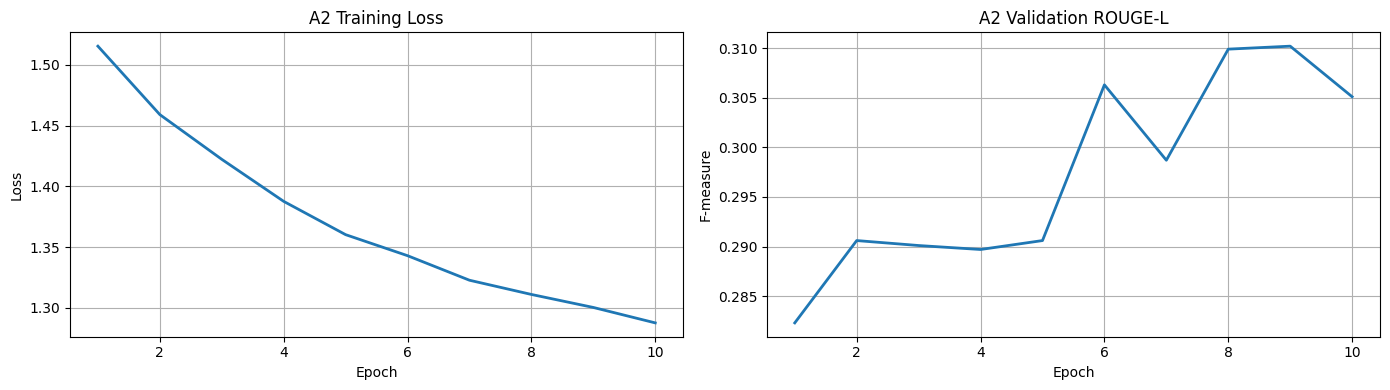

✅ Plot saved at: outputs/training_curves_a2.png


In [79]:
import sys
import subprocess
import pandas as pd

# Install matplotlib only if missing
try:
    import matplotlib.pyplot as plt
    print("✅ matplotlib already installed")
except ModuleNotFoundError:
    print("Installing matplotlib...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt
    print("✅ matplotlib installed")

# Create history dataframe
hist_df = pd.DataFrame(history)

# Plot curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], lw=2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("A2 Training Loss")
axes[0].grid(True)

axes[1].plot(hist_df["epoch"], hist_df["val_rougeL"], lw=2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F-measure")
axes[1].set_title("A2 Validation ROUGE-L")
axes[1].grid(True)

plt.tight_layout()

plot_path = OUTPUT_DIR / "training_curves_a2.png"
plt.savefig(plot_path, dpi=150)
plt.show()

print(f"✅ Plot saved at: {plot_path}")

## 🧪 Step 21 — Test evaluation

In [80]:
print("Loading best checkpoint …")
ckpt = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(ckpt["state_dict"])
print(f"✅ Loaded epoch {ckpt['epoch']}  (val ROUGE-L = {ckpt['best_rougeL']:.4f})")


Loading best checkpoint …
✅ Loaded epoch 9  (val ROUGE-L = 0.3102)


In [81]:
model.eval()
all_refs, all_hyps, all_uids = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Generating"):
        frontal = batch["image"][:, 0].to(DEVICE)
        lateral = batch["image"][:, 1].to(DEVICE)
        ctx_ids = batch["ctx_ids"].to(DEVICE)
        gen_ids = model.generate(frontal, lateral, ctx_ids)
        for i, ref in enumerate(batch["report_text"]):
            hyp = tokenizer.decode(gen_ids[i].tolist())
            all_refs.append(ref)
            all_hyps.append(hyp)
            all_uids.append(batch["uid"][i].item())

print(f"✅ Generated {len(all_refs)} reports")


Generating: 100%|██████████| 28/28 [01:10<00:00,  2.51s/it]

✅ Generated 442 reports


In [82]:
_smooth  = SmoothingFunction().method1
refs_tok = [[r.split()] for r in all_refs]
hyps_tok = [h.split()   for h in all_hyps]

bleu1 = corpus_bleu(refs_tok, hyps_tok, weights=(1,0,0,0),             smoothing_function=_smooth)
bleu2 = corpus_bleu(refs_tok, hyps_tok, weights=(0.5,0.5,0,0),         smoothing_function=_smooth)
bleu3 = corpus_bleu(refs_tok, hyps_tok, weights=(0.33,0.33,0.33,0),    smoothing_function=_smooth)
bleu4 = corpus_bleu(refs_tok, hyps_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=_smooth)

sc = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
rl = float(np.mean([sc.score(r,h)["rougeL"].fmeasure for r,h in zip(all_refs,all_hyps)]))

results = {
    "BL-1":    round(bleu1, 3),
    "BL-2":    round(bleu2, 3),
    "BL-3":    round(bleu3, 3),
    "BL-4":    round(bleu4, 3),
    "ROUGE-L": round(rl,    3),
}

print("\n" + "="*45)
print("  A2 TEST RESULTS (R2Gen + Retrieval)")
print("="*45)
for k, v in results.items():
    print(f"  {k:<12}: {v:.3f}")
print("="*45)
print("\n→ Copy these into your ablation study table row A2")



  A2 TEST RESULTS (R2Gen + Retrieval)
  BL-1        : 0.221
  BL-2        : 0.146
  BL-3        : 0.102
  BL-4        : 0.068
  ROUGE-L     : 0.302

→ Copy these into your ablation study table row A2


## 💾 Step 22 — Save outputs as JSON & download

In [83]:
import json
import pandas as pd
from IPython.display import FileLink, display

all_outputs = {
    "model": "A2: R2Gen + Retrieval",
    "top_k": TOP_K,
    "num_epochs": NUM_EPOCHS,
    "summary_metrics": results,
    "checkpoint_info": {
        "epoch": int(ckpt["epoch"]),
        "best_rougeL": float(ckpt["best_rougeL"]),
    },
    "training_history": pd.read_csv(OUTPUT_DIR / "training_history_a2.csv").to_dict(orient="records"),
    "predictions": [
        {"uid": all_uids[i], "reference": all_refs[i], "prediction": all_hyps[i]}
        for i in range(len(all_refs))
    ],
}

json_path = OUTPUT_DIR / "A2_outputs.json"

with open(json_path, "w") as f:
    json.dump(all_outputs, f, indent=2)

print("Saved to:", json_path)
print("Absolute path:", json_path.resolve())
print("Exists:", json_path.exists())

with open(json_path, "r") as f:
    check_data = json.load(f)

print("Reload check passed")
print("Predictions saved:", len(check_data["predictions"]))

display(FileLink(str(json_path)))

Saved to: outputs/A2_outputs.json
Absolute path: /home/jupyter-st126671/outputs/A2_outputs.json
Exists: True
Reload check passed
Predictions saved: 442


/home/jupyter-st126671/outputs/A2_outputs.json